Mencari file data Pristine Bragg Peak di dalam 'run 200'...
Berhasil mendeteksi 24 file simulasi energi.

Menjalankan mesin optimasi L-BFGS-B...

 HASIL OPTIMASI BOBOT PARTIKEL (24 LAYER ENERGI)
Layer  1 | File: run 200\Pristine_189.74MeV.csv | Bobot:   49010 partikel
Layer  2 | File: run 200\Pristine_190.19MeV.csv | Bobot:   18695 partikel
Layer  3 | File: run 200\Pristine_190.64MeV.csv | Bobot:       1 partikel
Layer  4 | File: run 200\Pristine_191.09MeV.csv | Bobot:       1 partikel
Layer  5 | File: run 200\Pristine_191.54MeV.csv | Bobot:    3160 partikel
Layer  6 | File: run 200\Pristine_191.99MeV.csv | Bobot:   18171 partikel
Layer  7 | File: run 200\Pristine_192.44MeV.csv | Bobot:   29924 partikel
Layer  8 | File: run 200\Pristine_192.88MeV.csv | Bobot:   24823 partikel
Layer  9 | File: run 200\Pristine_193.33MeV.csv | Bobot:   10502 partikel
Layer 10 | File: run 200\Pristine_193.77MeV.csv | Bobot:     784 partikel
Layer 11 | File: run 200\Pristine_194.22MeV.csv | Bobot:    3890 

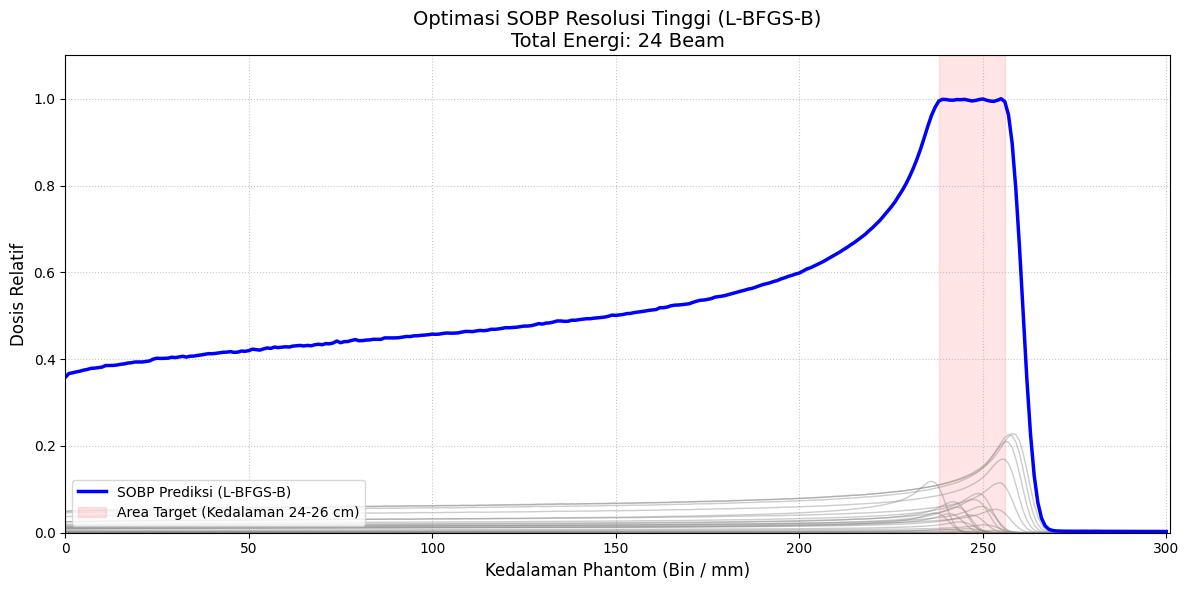

In [35]:
import pandas as pd #200
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import glob
import re
import os

# ==========================================
# 1. PENGATURAN TARGET & AUTO-LOAD FILE
# ==========================================
target_start = 238  # Sisi proksimal tumor (Bineex 130)
target_end = 256 # Sisi distal tumor (Bin 150)
maksimal_partikel = 100000 # Skala maksimal partikel untuk TOPAS

# --- PENGATURAN FOLDER ---
# Tuliskan nama folder tempat file CSV berada di sini
folder_target = "run 200" 

# Gabungkan nama folder dengan pola pencarian (menjadi: folder_120/Pristine_*.csv)
pola_pencarian = os.path.join(folder_target, "Pristine_*.csv")

print(f"Mencari file data Pristine Bragg Peak di dalam '{folder_target}'...")
file_list_mentah = glob.glob(pola_pencarian)

# Fungsi pintar untuk membaca angka energi HANYA dari nama filenya saja
def ambil_energi(nama_file):
    # Baru cari angka di dalam "Pristine_104.17MeV.csv"
    angka = re.findall(r"\d+\.\d+|\d+", nama_file)
    return float(angka[0]) if angka else 0.0

# Mengurutkan file dari energi paling besar (terdalam) ke paling kecil
file_list = sorted(file_list_mentah, key=ambil_energi, reverse=True)

if not file_list:
    print("ERROR: Tidak ada file Pristine_*.csv yang ditemukan di folder ini!")
else:
    print(f"Berhasil mendeteksi {len(file_list)} file simulasi energi.")

# ==========================================
# 2. EKSTRAKSI DATA & PENYUSUNAN MATRIKS
# ==========================================
dose_matrix = []
for file in file_list:
    # Membaca CSV, mengabaikan header TOPAS, mengambil kolom paling kanan
    df = pd.read_csv(file, comment='#', header=None)
    dose_array = df.iloc[:, -1].values
    dose_matrix.append(dose_array)

# Menyeragamkan jumlah bin (memotong jika ada file yang bin-nya lebih panjang)
min_len = min(len(arr) for arr in dose_matrix)
dose_matrix_cropped = [arr[:min_len] for arr in dose_matrix]
D = np.column_stack(dose_matrix_cropped)

# NORMALISASI MATRIKS (Kunci Utama Mencegah L-BFGS-B Mogok)
D_max = np.max(D)
D_norm = D / D_max

# Membuat Garis Target SOBP (Dosis disetel 1.0 di area tumor)
t = np.zeros(min_len)
t[target_start:target_end + 1] = 1.0

# ==========================================
# 3. FUNGSI LOSS KUSTOM (DENGAN PENALTI)
# ==========================================
def loss_function(w, D_mat, target):
    prediksi = D_mat.dot(w)
    
    dosis_area_tumor = prediksi[target_start:target_end+1]
    target_area_tumor = target[target_start:target_end+1]
    
    error_dasar = (dosis_area_tumor - target_area_tumor)**2
    
    # Penalti 5x lipat jika ada tonjolan dosis > 1.0
    error_penalti = np.where(dosis_area_tumor > target_area_tumor, error_dasar * 5.0, error_dasar)
    
    return np.mean(error_penalti)
    
# ==========================================
# 4. EKSEKUSI OPTIMASI TPS (L-BFGS-B)
# ==========================================
print("\nMenjalankan mesin optimasi L-BFGS-B...")
# Tebakan awal (Initial Guess) disetel 0.1 partikel relatif
w0 = np.ones(D_norm.shape[1]) * 0.1 

# Bobot tidak boleh bernilai minus
batas = [(0, None) for _ in range(D_norm.shape[1])]
hasil = minimize(loss_function, w0, args=(D_norm, t), method='L-BFGS-B', bounds=batas)

w_terbaik = hasil.x


# ==========================================
# 5. KONVERSI KE JUMLAH PARTIKEL TOPAS
# ==========================================
max_w = np.max(w_terbaik)
if max_w > 0:
    bobot_partikel = np.round((w_terbaik / max_w) * maksimal_partikel).astype(int)
else:
    bobot_partikel = np.zeros(len(w_terbaik), dtype=int)

print(f"\n{'='*65}")
print(f" HASIL OPTIMASI BOBOT PARTIKEL ({len(file_list)} LAYER ENERGI)")
print(f"{'='*65}")
for i, bobot in enumerate(bobot_partikel):
    print(f"Layer {i+1:2d} | File: {file_list[i]:>15} | Bobot: {bobot:7d} partikel")
print(f"{'='*65}\n")

# ==========================================
# 6. VISUALISASI SOBP AKHIR
# ==========================================
SOBP_prediksi_norm = D_norm.dot(w_terbaik)
max_dose_pred = np.max(SOBP_prediksi_norm)

# Skala akhir plot disesuaikan agar puncak dosis tepat di angka 1.0 (Relatif)
SOBP_plot = SOBP_prediksi_norm / max_dose_pred
D_plot = D_norm / max_dose_pred
kedalaman_mm = np.arange(min_len)

plt.figure(figsize=(12, 6))

# Plot kurva 21 Pristine Beam individu
for i in range(len(w_terbaik)):
    if w_terbaik[i] > 0:
        plt.plot(kedalaman_mm, D_plot[:, i] * w_terbaik[i], color='gray', alpha=0.4, linewidth=1.0)

# Plot Kurva SOBP Gabungan
plt.plot(kedalaman_mm, SOBP_plot, 'b-', linewidth=2.5, label='SOBP Prediksi (L-BFGS-B)')

# Highlight Area Tumor Target
plt.axvspan(target_start, target_end, color='red', alpha=0.1, label='Area Target (Kedalaman 24-26 cm)')

plt.title(f'Optimasi SOBP Resolusi Tinggi (L-BFGS-B)\nTotal Energi: {len(file_list)} Beam', fontsize=14)
plt.xlabel('Kedalaman Phantom (Bin / mm)', fontsize=12)
plt.ylabel('Dosis Relatif', fontsize=12)
plt.xlim([0, min_len])
plt.ylim([0, 1.1])
plt.legend(loc='lower left')
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

# ==========================================
# 5. KONVERSI & SIMPAN KE FILE TXT FORMAT TOPAS
# ==========================================
max_w = np.max(w_terbaik)
if max_w > 0:
    bobot_partikel = np.round((w_terbaik / max_w) * maksimal_partikel).astype(int)
else:
    bobot_partikel = np.zeros(len(w_terbaik), dtype=int)

N = len(file_list)

# 1. Ekstrak ulang nilai energi dari nama file
energi_list = [ambil_energi(f) for f in file_list]

# 2. Buat string deret waktu (1.0 2.0 3.0 dst...)
times_str = " ".join([f"{i+1}.0" for i in range(N)])

# 3. Buat string deret energi (dengan 4 angka di belakang koma)
energi_str = " ".join([f"{e:.4f}" for e in energi_list])

# 4. Buat string deret bobot partikel (dalam bentuk integer)
bobot_str = " ".join([str(b) for b in bobot_partikel])

# 5. Susun menjadi format Time Feature TOPAS
topas_text = f"""dv:Tf/LapisanEnergi/Times  = {N} {times_str} s
dv:Tf/LapisanEnergi/Values = {N} {energi_str} MeV

s:Tf/BobotPartikel/Function = "Step"
dv:Tf/BobotPartikel/Times  = {N} {times_str} s
iv:Tf/BobotPartikel/Values = {N} {bobot_str}
"""



In [15]:
import pandas as pd
import numpy as np

# 1. Load data hasil simulasi TOPAS
# Ganti 'hasil_simulasi.csv' dengan file kamu
df = pd.read_csv('hasil_simulasi.csv') 

# 2. Filter data sesuai rentang target (238 - 256 mm)
target_data = df[(df['depth'] >= 238) & (df['depth'] <= 256)]

# 3. Ambil nilai dosis
dosis = target_data['dose_value']

# 4. Hitung D2 dan D98
# Menggunakan persentil karena kita bicara tentang distribusi dosis dalam volume
D2 = np.percentile(dosis, 98) # Dosis tinggi (2% teratas)
D98 = np.percentile(dosis, 2) # Dosis rendah (98% terbawah)
Dp = np.mean(dosis)           # Atau gunakan nilai dosis preskripsi

# 5. Hitung Homogeneity Index
HI = (D2 - D98) / Dp

print(f"Homogeneity Index: {HI:.4f}")

FileNotFoundError: [Errno 2] No such file or directory: 'hasil_simulasi.csv'

In [6]:
import os
print("Pindahkan file ke folder ini:", os.getcwd())

Pindahkan file ke folder ini: C:\Users\Asus\Downloads


Mencari file data Pristine Bragg Peak di dalam 'run 120'...
Berhasil mendeteksi 24 file simulasi energi.

Menjalankan mesin optimasi L-BFGS-B...

 HASIL OPTIMASI BOBOT PARTIKEL (24 LAYER ENERGI)
Layer  1 | File: run 120\Pristine_119.78MeV.csv | Bobot:   74732 partikel
Layer  2 | File: run 120\Pristine_119.14MeV.csv | Bobot:   82170 partikel
Layer  3 | File: run 120\Pristine_118.49MeV.csv | Bobot:   93389 partikel
Layer  4 | File: run 120\Pristine_117.84MeV.csv | Bobot:  100000 partikel
Layer  5 | File: run 120\Pristine_117.18MeV.csv | Bobot:   74272 partikel
Layer  6 | File: run 120\Pristine_116.53MeV.csv | Bobot:   30342 partikel
Layer  7 | File: run 120\Pristine_115.87MeV.csv | Bobot:   33759 partikel
Layer  8 | File: run 120\Pristine_115.20MeV.csv | Bobot:   45505 partikel
Layer  9 | File: run 120\Pristine_114.54MeV.csv | Bobot:   23702 partikel
Layer 10 | File: run 120\Pristine_113.87MeV.csv | Bobot:   29602 partikel
Layer 11 | File: run 120\Pristine_113.20MeV.csv | Bobot:   32292 

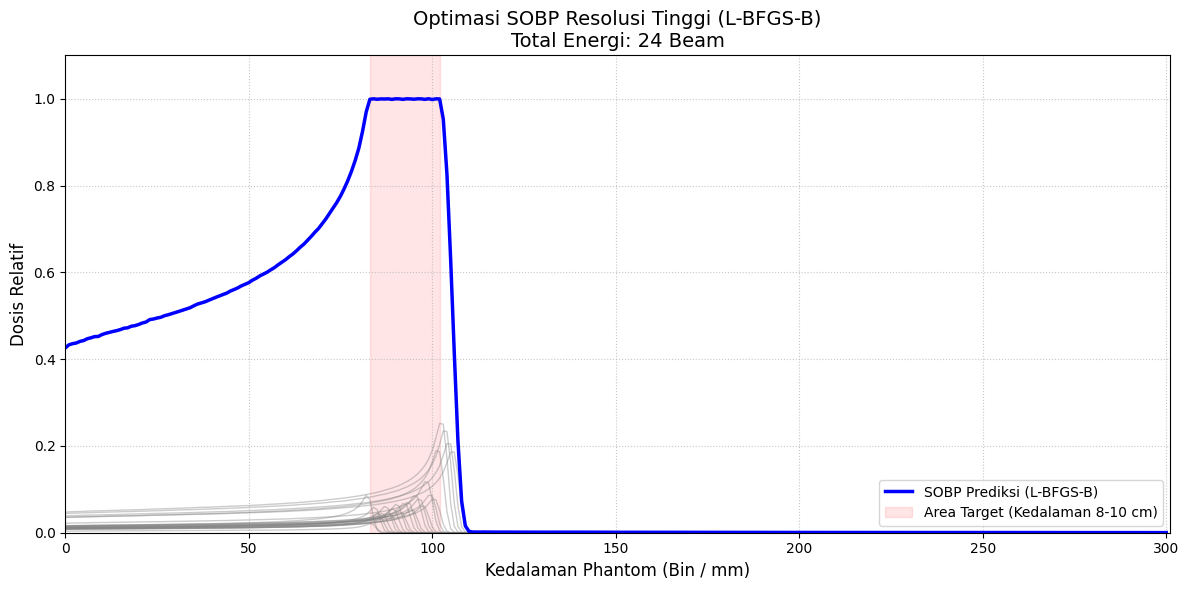


[SUKSES] Parameter berhasil dibuat dan disimpan di file: parameter_tps_topas.txt

-----------------------------------------------------------------
dv:Tf/LapisanEnergi/Times  = 24 1.0 2.0 3.0 4.0 5.0 6.0 7.0 8.0 9.0 10.0 11.0 12.0 13.0 14.0 15.0 16.0 17.0 18.0 19.0 20.0 21.0 22.0 23.0 24.0 s
dv:Tf/LapisanEnergi/Values = 24 119.7800 119.1400 118.4900 117.8400 117.1800 116.5300 115.8700 115.2000 114.5400 113.8700 113.2000 112.5200 111.8500 111.1700 110.4800 109.7900 109.1000 108.4100 107.7100 107.0100 106.3000 105.6000 104.8800 104.1700 MeV

s:Tf/BobotPartikel/Function = "Step"
dv:Tf/BobotPartikel/Times  = 24 1.0 2.0 3.0 4.0 5.0 6.0 7.0 8.0 9.0 10.0 11.0 12.0 13.0 14.0 15.0 16.0 17.0 18.0 19.0 20.0 21.0 22.0 23.0 24.0 s
iv:Tf/BobotPartikel/Values = 24 74732 82170 93389 100000 74272 30342 33759 45505 23702 29602 32292 20061 26110 25218 17624 23998 20055 16110 21937 16155 15886 20760 7404 30161

-----------------------------------------------------------------


In [14]:
import pandas as pd #120
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import glob
import re
import os

# ==========================================
# 1. PENGATURAN TARGET & AUTO-LOAD FILE
# ==========================================
target_start = 83  # Sisi proksimal tumor (Bineex 130)
target_end = 102 # Sisi distal tumor (Bin 150)
maksimal_partikel = 100000 # Skala maksimal partikel untuk TOPAS

# --- PENGATURAN FOLDER ---
# Tuliskan nama folder tempat file CSV berada di sini
folder_target = "run 120" 

# Gabungkan nama folder dengan pola pencarian (menjadi: folder_120/Pristine_*.csv)
pola_pencarian = os.path.join(folder_target, "Pristine_*.csv")

print(f"Mencari file data Pristine Bragg Peak di dalam '{folder_target}'...")
file_list_mentah = glob.glob(pola_pencarian)

# Fungsi pintar untuk membaca angka energi HANYA dari nama filenya saja
def ambil_energi(nama_file):
    # Buang nama path foldernya (contoh: "run 120\Pristine_104.17MeV.csv" jadi "Pristine_104.17MeV.csv")
    nama_saja = os.path.basename(nama_file)
    
    # Baru cari angka di dalam "Pristine_104.17MeV.csv"
    angka = re.findall(r"\d+\.\d+|\d+", nama_saja)
    return float(angka[0]) if angka else 0.0

# Mengurutkan file dari energi paling besar (terdalam) ke paling kecil
file_list = sorted(file_list_mentah, key=ambil_energi, reverse=True)

if not file_list:
    print("ERROR: Tidak ada file Pristine_*.csv yang ditemukan di folder ini!")
else:
    print(f"Berhasil mendeteksi {len(file_list)} file simulasi energi.")

# ==========================================
# 2. EKSTRAKSI DATA & PENYUSUNAN MATRIKS
# ==========================================
dose_matrix = []
for file in file_list:
    # Membaca CSV, mengabaikan header TOPAS, mengambil kolom paling kanan
    df = pd.read_csv(file, comment='#', header=None)
    dose_array = df.iloc[:, -1].values
    dose_matrix.append(dose_array)

# Menyeragamkan jumlah bin (memotong jika ada file yang bin-nya lebih panjang)
min_len = min(len(arr) for arr in dose_matrix)
dose_matrix_cropped = [arr[:min_len] for arr in dose_matrix]
D = np.column_stack(dose_matrix_cropped)

# NORMALISASI MATRIKS (Kunci Utama Mencegah L-BFGS-B Mogok)
D_max = np.max(D)
D_norm = D / D_max

# Membuat Garis Target SOBP (Dosis disetel 1.0 di area tumor)
t = np.zeros(min_len)
t[target_start:target_end + 1] = 1.0

# ==========================================
# 3. FUNGSI LOSS KUSTOM (DENGAN PENALTI)
# ==========================================
def loss_function(w, D_mat, target):
    prediksi = D_mat.dot(w)
    
    dosis_area_tumor = prediksi[target_start:target_end+1]
    target_area_tumor = target[target_start:target_end+1]
    
    error_dasar = (dosis_area_tumor - target_area_tumor)**2
    
    # Penalti 5x lipat jika ada tonjolan dosis > 1.0
    error_penalti = np.where(dosis_area_tumor > target_area_tumor, error_dasar * 5.0, error_dasar)
    
    return np.mean(error_penalti)
    
# ==========================================
# 4. EKSEKUSI OPTIMASI TPS (L-BFGS-B)
# ==========================================
print("\nMenjalankan mesin optimasi L-BFGS-B...")
# Tebakan awal (Initial Guess) disetel 0.1 partikel relatif
w0 = np.ones(D_norm.shape[1]) * 0.1 

# Bobot tidak boleh bernilai minus
batas = [(0, None) for _ in range(D_norm.shape[1])]
hasil = minimize(loss_function, w0, args=(D_norm, t), method='L-BFGS-B', bounds=batas)

w_terbaik = hasil.x


# ==========================================
# 5. KONVERSI KE JUMLAH PARTIKEL TOPAS
# ==========================================
max_w = np.max(w_terbaik)
if max_w > 0:
    bobot_partikel = np.round((w_terbaik / max_w) * maksimal_partikel).astype(int)
else:
    bobot_partikel = np.zeros(len(w_terbaik), dtype=int)

print(f"\n{'='*65}")
print(f" HASIL OPTIMASI BOBOT PARTIKEL ({len(file_list)} LAYER ENERGI)")
print(f"{'='*65}")
for i, bobot in enumerate(bobot_partikel):
    print(f"Layer {i+1:2d} | File: {file_list[i]:>15} | Bobot: {bobot:7d} partikel")
print(f"{'='*65}\n")

# ==========================================
# 6. VISUALISASI SOBP AKHIR
# ==========================================
SOBP_prediksi_norm = D_norm.dot(w_terbaik)
max_dose_pred = np.max(SOBP_prediksi_norm)

# Skala akhir plot disesuaikan agar puncak dosis tepat di angka 1.0 (Relatif)
SOBP_plot = SOBP_prediksi_norm / max_dose_pred
D_plot = D_norm / max_dose_pred
kedalaman_mm = np.arange(min_len)

plt.figure(figsize=(12, 6))

# Plot kurva 21 Pristine Beam individu
for i in range(len(w_terbaik)):
    if w_terbaik[i] > 0:
        plt.plot(kedalaman_mm, D_plot[:, i] * w_terbaik[i], color='gray', alpha=0.4, linewidth=1.0)

# Plot Kurva SOBP Gabungan
plt.plot(kedalaman_mm, SOBP_plot, 'b-', linewidth=2.5, label='SOBP Prediksi (L-BFGS-B)')

# Highlight Area Tumor Target
plt.axvspan(target_start, target_end, color='red', alpha=0.1, label='Area Target (Kedalaman 8-10 cm)')

plt.title(f'Optimasi SOBP Resolusi Tinggi (L-BFGS-B)\nTotal Energi: {len(file_list)} Beam', fontsize=14)
plt.xlabel('Kedalaman Phantom (Bin / mm)', fontsize=12)
plt.ylabel('Dosis Relatif', fontsize=12)
plt.xlim([0, min_len])
plt.ylim([0, 1.1])
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

# ==========================================
# 5. KONVERSI & SIMPAN KE FILE TXT FORMAT TOPAS
# ==========================================
max_w = np.max(w_terbaik)
if max_w > 0:
    bobot_partikel = np.round((w_terbaik / max_w) * maksimal_partikel).astype(int)
else:
    bobot_partikel = np.zeros(len(w_terbaik), dtype=int)

N = len(file_list)

# 1. Ekstrak ulang nilai energi dari nama file
energi_list = [ambil_energi(f) for f in file_list]

# 2. Buat string deret waktu (1.0 2.0 3.0 dst...)
times_str = " ".join([f"{i+1}.0" for i in range(N)])

# 3. Buat string deret energi (dengan 4 angka di belakang koma)
energi_str = " ".join([f"{e:.4f}" for e in energi_list])

# 4. Buat string deret bobot partikel (dalam bentuk integer)
bobot_str = " ".join([str(b) for b in bobot_partikel])

# 5. Susun menjadi format Time Feature TOPAS
topas_text = f"""dv:Tf/LapisanEnergi/Times  = {N} {times_str} s
dv:Tf/LapisanEnergi/Values = {N} {energi_str} MeV

s:Tf/BobotPartikel/Function = "Step"
dv:Tf/BobotPartikel/Times  = {N} {times_str} s
iv:Tf/BobotPartikel/Values = {N} {bobot_str}
"""

# Simpan ke file teks
nama_file_txt = "parameter_tps_topas.txt"
with open(nama_file_txt, "w") as f:
    f.write(topas_text)

# Cetak di layar untuk memastikan
print(f"\n[SUKSES] Parameter berhasil dibuat dan disimpan di file: {nama_file_txt}\n")
print("-" * 65)
print(topas_text)
print("-" * 65)

Mencari file data Pristine Bragg Peak di dalam 'run 152'...
Berhasil mendeteksi 24 file simulasi energi.

Menjalankan mesin optimasi L-BFGS-B...

 HASIL OPTIMASI BOBOT PARTIKEL (24 LAYER ENERGI)
Layer  1 | File: run 152\Pristine_150.00MeV.csv | Bobot:   75751 partikel
Layer  2 | File: run 152\Pristine_149.27MeV.csv | Bobot:   80318 partikel
Layer  3 | File: run 152\Pristine_148.72MeV.csv | Bobot:   85448 partikel
Layer  4 | File: run 152\Pristine_148.17MeV.csv | Bobot:   91236 partikel
Layer  5 | File: run 152\Pristine_147.63MeV.csv | Bobot:   97935 partikel
Layer  6 | File: run 152\Pristine_147.08MeV.csv | Bobot:  100000 partikel
Layer  7 | File: run 152\Pristine_146.53MeV.csv | Bobot:   85770 partikel
Layer  8 | File: run 152\Pristine_145.97MeV.csv | Bobot:   57507 partikel
Layer  9 | File: run 152\Pristine_145.42MeV.csv | Bobot:   31377 partikel
Layer 10 | File: run 152\Pristine_144.86MeV.csv | Bobot:   28912 partikel
Layer 11 | File: run 152\Pristine_144.31MeV.csv | Bobot:   43150 

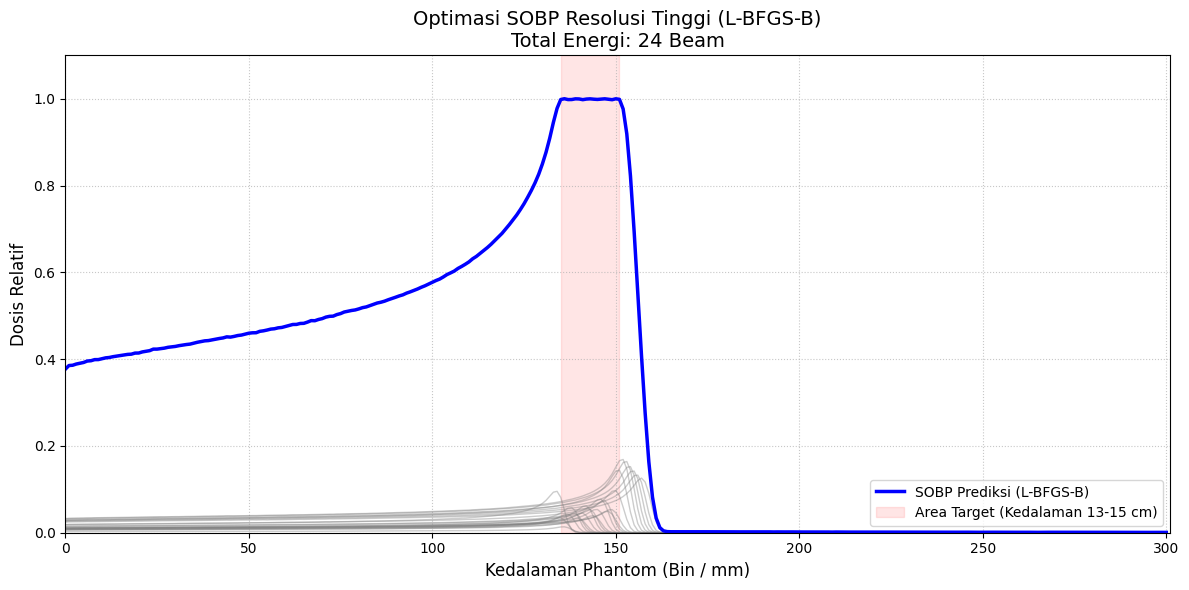


[SUKSES] Parameter berhasil dibuat dan disimpan di file: parameter_tps_topas.txt

-----------------------------------------------------------------
dv:Tf/LapisanEnergi/Times  = 24 1.0 2.0 3.0 4.0 5.0 6.0 7.0 8.0 9.0 10.0 11.0 12.0 13.0 14.0 15.0 16.0 17.0 18.0 19.0 20.0 21.0 22.0 23.0 24.0 s
dv:Tf/LapisanEnergi/Values = 24 150.0000 149.2700 148.7200 148.1700 147.6300 147.0800 146.5300 145.9700 145.4200 144.8600 144.3100 143.7500 143.1900 142.6200 142.0600 141.4900 140.9200 140.3500 139.7800 139.2100 138.6400 138.0600 137.4800 136.9000 MeV

s:Tf/BobotPartikel/Function = "Step"
dv:Tf/BobotPartikel/Times  = 24 1.0 2.0 3.0 4.0 5.0 6.0 7.0 8.0 9.0 10.0 11.0 12.0 13.0 14.0 15.0 16.0 17.0 18.0 19.0 20.0 21.0 22.0 23.0 24.0 s
iv:Tf/BobotPartikel/Values = 24 75751 80318 85448 91236 97935 100000 85770 57507 31377 28912 43150 45057 31106 22609 30800 35421 25847 18520 24912 32845 24059 7599 19037 53393

-----------------------------------------------------------------


In [39]:
import pandas as pd #150
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import glob
import re
import os

# ==========================================
# 1. PENGATURAN TARGET & AUTO-LOAD FILE
# ==========================================
target_start = 135  # Sisi proksimal tumor (Bineex 130)
target_end = 151 # Sisi distal tumor (Bin 150)
maksimal_partikel = 100000 # Skala maksimal partikel untuk TOPAS

# --- PENGATURAN FOLDER ---
# Tuliskan nama folder tempat file CSV berada di sini
folder_target = "run 152" 

# Gabungkan nama folder dengan pola pencarian (menjadi: folder_120/Pristine_*.csv)
pola_pencarian = os.path.join(folder_target, "Pristine_*.csv")

print(f"Mencari file data Pristine Bragg Peak di dalam '{folder_target}'...")
file_list_mentah = glob.glob(pola_pencarian)

# Fungsi pintar untuk membaca angka energi HANYA dari nama filenya saja
def ambil_energi(nama_file):
    # Buang nama path foldernya (contoh: "run 120\Pristine_104.17MeV.csv" jadi "Pristine_104.17MeV.csv")
    nama_saja = os.path.basename(nama_file)
    
    # Baru cari angka di dalam "Pristine_104.17MeV.csv"
    angka = re.findall(r"\d+\.\d+|\d+", nama_saja)
    return float(angka[0]) if angka else 0.0

# Mengurutkan file dari energi paling besar (terdalam) ke paling kecil
file_list = sorted(file_list_mentah, key=ambil_energi, reverse=True)

if not file_list:
    print("ERROR: Tidak ada file Pristine_*.csv yang ditemukan di folder ini!")
else:
    print(f"Berhasil mendeteksi {len(file_list)} file simulasi energi.")

# ==========================================
# 2. EKSTRAKSI DATA & PENYUSUNAN MATRIKS
# ==========================================
dose_matrix = []
for file in file_list:
    # Membaca CSV, mengabaikan header TOPAS, mengambil kolom paling kanan
    df = pd.read_csv(file, comment='#', header=None)
    dose_array = df.iloc[:, -1].values
    dose_matrix.append(dose_array)

# Menyeragamkan jumlah bin (memotong jika ada file yang bin-nya lebih panjang)
min_len = min(len(arr) for arr in dose_matrix)
dose_matrix_cropped = [arr[:min_len] for arr in dose_matrix]
D = np.column_stack(dose_matrix_cropped)

# NORMALISASI MATRIKS (Kunci Utama Mencegah L-BFGS-B Mogok)
D_max = np.max(D)
D_norm = D / D_max

# Membuat Garis Target SOBP (Dosis disetel 1.0 di area tumor)
t = np.zeros(min_len)
t[target_start:target_end + 1] = 1.0

# ==========================================
# 3. FUNGSI LOSS KUSTOM (DENGAN PENALTI)
# ==========================================
def loss_function(w, D_mat, target):
    prediksi = D_mat.dot(w)
    
    dosis_area_tumor = prediksi[target_start:target_end+1]
    target_area_tumor = target[target_start:target_end+1]
    
    error_dasar = (dosis_area_tumor - target_area_tumor)**2
    
    # Penalti 5x lipat jika ada tonjolan dosis > 1.0
    error_penalti = np.where(dosis_area_tumor > target_area_tumor, error_dasar * 5.0, error_dasar)
    
    return np.mean(error_penalti)
    
# ==========================================
# 4. EKSEKUSI OPTIMASI TPS (L-BFGS-B)
# ==========================================
print("\nMenjalankan mesin optimasi L-BFGS-B...")
# Tebakan awal (Initial Guess) disetel 0.1 partikel relatif
w0 = np.ones(D_norm.shape[1]) * 0.1 

# Bobot tidak boleh bernilai minus
batas = [(0, None) for _ in range(D_norm.shape[1])]
hasil = minimize(loss_function, w0, args=(D_norm, t), method='L-BFGS-B', bounds=batas)

w_terbaik = hasil.x


# ==========================================
# 5. KONVERSI KE JUMLAH PARTIKEL TOPAS
# ==========================================
max_w = np.max(w_terbaik)
if max_w > 0:
    bobot_partikel = np.round((w_terbaik / max_w) * maksimal_partikel).astype(int)
else:
    bobot_partikel = np.zeros(len(w_terbaik), dtype=int)

print(f"\n{'='*65}")
print(f" HASIL OPTIMASI BOBOT PARTIKEL ({len(file_list)} LAYER ENERGI)")
print(f"{'='*65}")
for i, bobot in enumerate(bobot_partikel):
    print(f"Layer {i+1:2d} | File: {file_list[i]:>15} | Bobot: {bobot:7d} partikel")
print(f"{'='*65}\n")

# ==========================================
# 6. VISUALISASI SOBP AKHIR
# ==========================================
SOBP_prediksi_norm = D_norm.dot(w_terbaik)
max_dose_pred = np.max(SOBP_prediksi_norm)

# Skala akhir plot disesuaikan agar puncak dosis tepat di angka 1.0 (Relatif)
SOBP_plot = SOBP_prediksi_norm / max_dose_pred
D_plot = D_norm / max_dose_pred
kedalaman_mm = np.arange(min_len)

plt.figure(figsize=(12, 6))

# Plot kurva 21 Pristine Beam individu
for i in range(len(w_terbaik)):
    if w_terbaik[i] > 0:
        plt.plot(kedalaman_mm, D_plot[:, i] * w_terbaik[i], color='gray', alpha=0.4, linewidth=1.0)

# Plot Kurva SOBP Gabungan
plt.plot(kedalaman_mm, SOBP_plot, 'b-', linewidth=2.5, label='SOBP Prediksi (L-BFGS-B)')

# Highlight Area Tumor Target
plt.axvspan(target_start, target_end, color='red', alpha=0.1, label='Area Target (Kedalaman 13-15 cm)')

plt.title(f'Optimasi SOBP Resolusi Tinggi (L-BFGS-B)\nTotal Energi: {len(file_list)} Beam', fontsize=14)
plt.xlabel('Kedalaman Phantom (Bin / mm)', fontsize=12)
plt.ylabel('Dosis Relatif', fontsize=12)
plt.xlim([0, min_len])
plt.ylim([0, 1.1])
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

# ==========================================
# 5. KONVERSI & SIMPAN KE FILE TXT FORMAT TOPAS
# ==========================================
max_w = np.max(w_terbaik)
if max_w > 0:
    bobot_partikel = np.round((w_terbaik / max_w) * maksimal_partikel).astype(int)
else:
    bobot_partikel = np.zeros(len(w_terbaik), dtype=int)

N = len(file_list)

# 1. Ekstrak ulang nilai energi dari nama file
energi_list = [ambil_energi(f) for f in file_list]

# 2. Buat string deret waktu (1.0 2.0 3.0 dst...)
times_str = " ".join([f"{i+1}.0" for i in range(N)])

# 3. Buat string deret energi (dengan 4 angka di belakang koma)
energi_str = " ".join([f"{e:.4f}" for e in energi_list])

# 4. Buat string deret bobot partikel (dalam bentuk integer)
bobot_str = " ".join([str(b) for b in bobot_partikel])

# 5. Susun menjadi format Time Feature TOPAS
topas_text = f"""dv:Tf/LapisanEnergi/Times  = {N} {times_str} s
dv:Tf/LapisanEnergi/Values = {N} {energi_str} MeV

s:Tf/BobotPartikel/Function = "Step"
dv:Tf/BobotPartikel/Times  = {N} {times_str} s
iv:Tf/BobotPartikel/Values = {N} {bobot_str}
"""

# Simpan ke file teks
nama_file_txt = "parameter_tps_topas.txt"
with open(nama_file_txt, "w") as f:
    f.write(topas_text)

# Cetak di layar untuk memastikan
print(f"\n[SUKSES] Parameter berhasil dibuat dan disimpan di file: {nama_file_txt}\n")
print("-" * 65)
print(topas_text)
print("-" * 65)

In [4]:
# ==========================================
# 1. PENGATURAN TARGET & AUTO-LOAD FILE
# ==========================================

target_start = 83
target_end = 102
maksimal_partikel = 100000

folder_target = "run 120"

pola_pencarian = os.path.join(
    folder_target,
    "Pristine_*.csv"
)

print(f"\nMencari file pada folder: {folder_target}")

file_list_mentah = glob.glob(
    pola_pencarian
)

# ==========================================
# FUNGSI BACA ENERGI DARI NAMA FILE
# ==========================================

def ambil_energi(nama_file):

    nama_saja = os.path.basename(
        nama_file
    )

    angka = re.findall(
        r"\d+\.\d+|\d+",
        nama_saja
    )

    if angka:
        return float(
            angka[0]
        )

    return 0.0


# urut energi tinggi → rendah
file_list = sorted(
    file_list_mentah,
    key=ambil_energi,
    reverse=True
)

# ==========================================
# VALIDASI FILE
# ==========================================

if len(file_list)==0:

    print("\nERROR")
    print(f"Tidak ada file cocok dengan:")
    print(pola_pencarian)

    print("\nIsi folder yang ditemukan:")

    semua = glob.glob(
        os.path.join(
            folder_target,
            "*.csv"
        )
    )

    for f in semua:
        print(
            os.path.basename(f)
        )

    raise FileNotFoundError(
        "Tidak ada file Pristine ditemukan."
    )

print(
    f"\nBerhasil membaca {len(file_list)} file:"
)

for i,f in enumerate(file_list):

    print(
        f"{i+1:2d}. "
        f"{os.path.basename(f)} "
        f"→ "
        f"{ambil_energi(f):.2f} MeV"
    )


# ==========================================
# 2. EKSTRAKSI DATA
# ==========================================

dose_matrix=[]

for file in file_list:

    try:

        df=pd.read_csv(
            file,
            comment="#",
            header=None
        )

        if df.empty:

            print(
                f"SKIP kosong: {file}"
            )

            continue

        dose_array=(
            df
            .iloc[:,-1]
            .astype(float)
            .values
        )

        dose_matrix.append(
            dose_array
        )

        print(
            f"OK "
            f"{os.path.basename(file)}"
            f" | "
            f"{len(dose_array)} bin"
        )

    except Exception as e:

        print(
            f"Gagal baca {file}"
        )

        print(e)

# ==========================================
# VALIDASI MATRIX
# ==========================================

if len(dose_matrix)==0:

    raise ValueError(
        "Semua file gagal dibaca."
    )

min_len=min(
    len(arr)
    for arr in dose_matrix
)

print(
    f"\nJumlah bin dipakai: {min_len}"
)

dose_matrix_cropped=[

    arr[:min_len]

    for arr

    in dose_matrix

]

D=np.column_stack(
    dose_matrix_cropped
)

print(
    f"Matriks dosis:"
)

print(
    D.shape
)

# ==========================================
# NORMALISASI MATRIKS
# ==========================================

D_max = np.max(D)

if D_max == 0:
    raise ValueError("Semua dosis = 0")

D_norm = D / D_max

# ==========================================
# TARGET SOBP
# ==========================================

t = np.zeros(min_len)

t[
target_start:
target_end+1
] = 1.0

# ==========================================
# LOSS FUNCTION
# ==========================================

def loss_function(
    w,
    D_mat,
    target
):

    pred = D_mat.dot(w)

    tumor = pred[
        target_start:
        target_end+1
    ]

    target_tumor = target[
        target_start:
        target_end+1
    ]

    err = (
        tumor
        -
        target_tumor
    )**2

    penalty = np.where(

        tumor >
        target_tumor,

        err*5,

        err

    )

    return np.mean(
        penalty
    )

# ==========================================
# OPTIMIZER
# ==========================================

print(
"\nMenjalankan optimasi..."
)

w0=np.ones(
D_norm.shape[1]
)*0.1

bounds=[

(0,None)

for _ in range(
D_norm.shape[1]
)

]

hasil=minimize(

loss_function,

w0,

args=(
D_norm,
t
),

method="L-BFGS-B",

bounds=bounds

)

if not hasil.success:

    print(
    hasil.message
    )

w_terbaik=hasil.x

# ==========================================
# KONVERSI JUMLAH PARTIKEL
# ==========================================

max_w=np.max(
w_terbaik
)

if max_w>0:

    bobot_partikel=np.round(

    (
    w_terbaik
    /
    max_w
    )

    *
    maksimal_partikel

    ).astype(
    int
    )

else:

    bobot_partikel=np.zeros(

    len(
    w_terbaik
    ),

    dtype=int

    )

# ==========================================
# TAMPILKAN HASIL
# ==========================================

print("\n")

print("="*80)

print(
"HASIL OPTIMASI PARTIKEL"
)

print("="*80)

energi_list=[

ambil_energi(f)

for f

in file_list

]

for i in range(

len(
bobot_partikel
)

):

    print(

    f"Layer {i+1:2d}"

    f" | "

    f"{energi_list[i]:7.2f} MeV"

    f" | "

    f"{bobot_partikel[i]:7d}"

    f" partikel"

    )

print("="*80)

# ==========================================
# SIMPAN TXT TOPAS
# ==========================================

N=len(
energi_list
)

times=" ".join(

[
f"{i+1}.0"

for i

in range(
N
)

]

)

energi_str=" ".join(

[
f"{x:.4f}"

for x

in energi_list

]

)

bobot_str=" ".join(

[
str(x)

for x

in bobot_partikel

]

)

txt=f"""
dv:Tf/LapisanEnergi/Times = {N} {times} s
dv:Tf/LapisanEnergi/Values = {N} {energi_str} MeV

s:Tf/BobotPartikel/Function = "Step"

dv:Tf/BobotPartikel/Times = {N} {times} s

iv:Tf/BobotPartikel/Values = {N} {bobot_str}
"""

with open(

"parameter_tps_topas.txt",

"w"

) as f:

    f.write(
    txt
    )

print(
"\nSUKSES → parameter_tps_topas.txt"
)


Mencari file pada folder: run 120

Berhasil membaca 24 file:
 1. Pristine_119.78MeV.csv → 119.78 MeV
 2. Pristine_119.14MeV.csv → 119.14 MeV
 3. Pristine_118.49MeV.csv → 118.49 MeV
 4. Pristine_117.84MeV.csv → 117.84 MeV
 5. Pristine_117.18MeV.csv → 117.18 MeV
 6. Pristine_116.53MeV.csv → 116.53 MeV
 7. Pristine_115.87MeV.csv → 115.87 MeV
 8. Pristine_115.20MeV.csv → 115.20 MeV
 9. Pristine_114.54MeV.csv → 114.54 MeV
10. Pristine_113.87MeV.csv → 113.87 MeV
11. Pristine_113.20MeV.csv → 113.20 MeV
12. Pristine_112.52MeV.csv → 112.52 MeV
13. Pristine_111.85MeV.csv → 111.85 MeV
14. Pristine_111.17MeV.csv → 111.17 MeV
15. Pristine_110.48MeV.csv → 110.48 MeV
16. Pristine_109.79MeV.csv → 109.79 MeV
17. Pristine_109.10MeV.csv → 109.10 MeV
18. Pristine_108.41MeV.csv → 108.41 MeV
19. Pristine_107.71MeV.csv → 107.71 MeV
20. Pristine_107.01MeV.csv → 107.01 MeV
21. Pristine_106.30MeV.csv → 106.30 MeV
22. Pristine_105.60MeV.csv → 105.60 MeV
23. Pristine_104.88MeV.csv → 104.88 MeV
24. Pristine_104.1